In [14]:
# --- IMPORTS ---
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [10]:
# --- 1. CHARGEMENT ET EXPLORATION ---
# Chargement du fichier CSV avec pandas (n'oublie pas le dossier 'data/' si tu as suivi ton README)
df = pd.read_csv('data/Tetuan PC Courrier.csv')

# Aperçu des 5 premières lignes pour vérifier
print("--- Aperçu des données ---")
display(df.head()) 

# Informations générales et vérification des valeurs manquantes
print("\n--- Informations sur le Dataset ---")
df.info() 

# Statistiques descriptives
print("\n--- Statistiques descriptives ---")
display(df.describe()) 

--- Aperçu des données ---


,DateTime,Temperature,Humidity,WindSpeed,GenDiffFlows,DiffFlows,PCZone1,PCZone2,PCZone3
24625,6/21/2017 0:00,21.86,77.0,0.081,0.073,0.111,44554.17219,24750.93555,26980.43077
24626,6/21/2017 0:10,21.91,76.0,0.077,0.077,0.096,44249.00662,24612.47401,26631.87692
24627,6/21/2017 0:20,21.96,75.5,0.081,0.055,0.096,43753.11258,24339.29314,26141.53846
24628,6/21/2017 0:30,21.83,75.1,0.078,0.062,0.163,43079.20530,24208.31601,26052.92308
24629,6/21/2017 0:40,21.60,75.8,0.075,0.048,0.145,42634.17219,23927.65073,25887.50769



--- Informations sur le Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 13248 entries, 24625 to 37872
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DateTime      13248 non-null  str    
 1   Temperature   13248 non-null  float64
 2   Humidity      13248 non-null  float64
 3   WindSpeed     13248 non-null  float64
 4   GenDiffFlows  13248 non-null  float64
 5   DiffFlows     13248 non-null  float64
 6   PCZone1       13248 non-null  float64
 7   PCZone2       13248 non-null  float64
 8   PCZone3       13248 non-null  float64
dtypes: float64(8), str(1)
memory usage: 931.6 KB

--- Statistiques descriptives ---


,Temperature,Humidity,WindSpeed,GenDiffFlows,DiffFlows,PCZone1,PCZone2,PCZone3
count,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000,13248.000000
mean,25.353431,63.239117,4.000284,254.436238,68.161448,35272.400777,22976.430993,23544.040816
std,3.687087,18.150509,1.857605,310.646997,91.721217,7073.784592,5239.586748,7667.598488
min,13.990000,11.340000,0.050000,0.018000,0.019000,18283.684790,10624.116420,8189.908069
25%,22.750000,50.260000,4.904000,0.088000,0.122000,29432.896780,18866.737060,17001.338912
50%,25.140000,65.050000,4.910000,61.540000,35.030000,35604.955750,22900.105600,23051.926500
75%,27.430000,78.300000,4.919000,526.100000,100.200000,40238.628617,27002.361105,28540.920500
max,40.010000,93.800000,4.998000,978.000000,558.700000,52204.395120,37408.860760,47598.326360


Question 1 : Il y a 13248 observations (lignes) et 9 variables (colonnes).

Question 2 : Nombre de valeurs manquantes par variable :
DateTime        0
Temperature     0
Humidity        0
WindSpeed       0
GenDiffFlows    0
DiffFlows       0
PCZone1         0
PCZone2         0
PCZone3         0
dtype: int64

 Aucune valeur manquante détectée. Pas besoin de suppression.


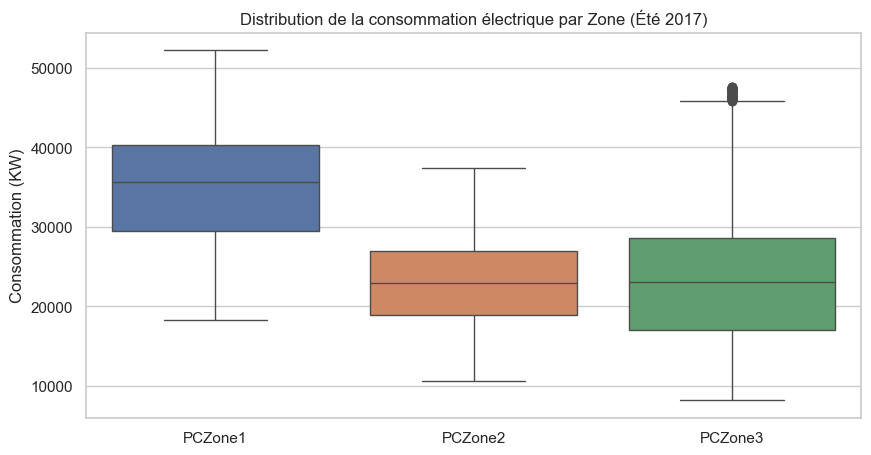

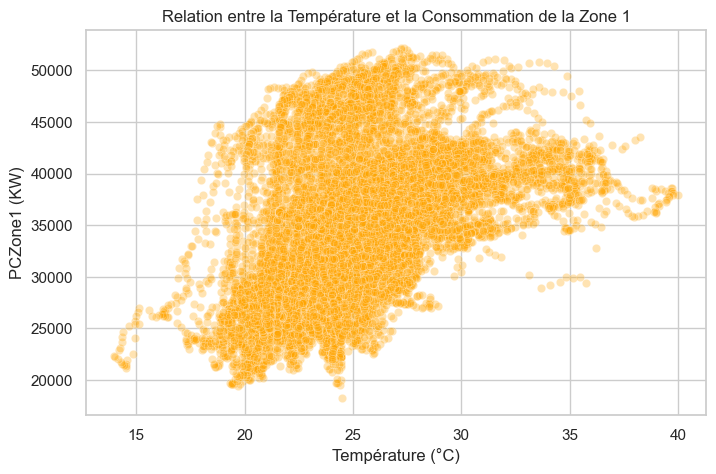

In [17]:
# --- 1.1 RÉPONSES AUX QUESTIONS 1 & 2 ---
# Extraction propre des dimensions
nb_lignes, nb_colonnes = df.shape
print(f"Question 1 : Il y a {nb_lignes} observations (lignes) et {nb_colonnes} variables (colonnes).")

# Vérification explicite des valeurs manquantes
valeurs_manquantes = df.isnull().sum()
print("\nQuestion 2 : Nombre de valeurs manquantes par variable :")
print(valeurs_manquantes)

if valeurs_manquantes.sum() > 0:
    print(f"\n {valeurs_manquantes.sum()} valeurs manquantes détectées. Nettoyage en cours...")
    df = df.dropna()  # Supprime les lignes contenant des valeurs manquantes
    print("Nettoyage effectué. Le dataset est nettoyé pour l'ACP et la régression.")
else:
    print("\n Aucune valeur manquante détectée. Pas besoin de suppression.")

# --- 1.2 VISUALISATIONS (QUESTION 3) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style des graphiques
%matplotlib inline
sns.set_theme(style="whitegrid")

# Graphique A : Boxplot des consommations pour comparer les 3 zones
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['PCZone1', 'PCZone2', 'PCZone3']])
plt.title("Distribution de la consommation électrique par Zone (Été 2017)")
plt.ylabel("Consommation (KW)")
plt.show()

# Graphique B : Scatter plot pour voir l'impact de la température sur la zone 1
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature', y='PCZone1', data=df, alpha=0.3, color='orange')
plt.title("Relation entre la Température et la Consommation de la Zone 1")
plt.xlabel("Température (°C)")
plt.ylabel("PCZone1 (KW)")
plt.show()

--- Variances des variables ---


Temperature    1.359500e+01
Humidity       3.294410e+02
WindSpeed      3.451000e+00
PCZone1        5.003843e+07
PCZone2        2.745327e+07
PCZone3        5.879207e+07
dtype: float64


--- Matrice de corrélation ---


,Temperature,Humidity,WindSpeed,PCZone1,PCZone2,PCZone3
Temperature,1.000,-0.609,0.177,0.456,0.572,0.526
Humidity,-0.609,1.000,-0.020,-0.267,-0.312,-0.277
WindSpeed,0.177,-0.020,1.000,0.055,0.128,0.319
PCZone1,0.456,-0.267,0.055,1.000,0.923,0.759
PCZone2,0.572,-0.312,0.128,0.923,1.000,0.828
PCZone3,0.526,-0.277,0.319,0.759,0.828,1.000



--- Vecteurs de chargement (Loadings) ---


,PC1,PC2,PC3,PC4,PC5,PC6
Temperature,0.415,-0.390,0.253,0.768,-0.077,-0.126
Humidity,-0.290,0.707,-0.253,0.591,-0.025,-0.035
WindSpeed,0.140,0.462,0.830,-0.139,-0.242,0.001
PCZone1,0.478,0.186,-0.352,-0.193,-0.467,-0.598
PCZone2,0.510,0.161,-0.243,-0.009,-0.223,0.778
PCZone3,0.485,0.272,-0.005,-0.064,0.816,-0.142



--- Pourcentage de Variance Expliquée (PVE) ---
PC1 : PVE = 55.49% | PVE Cumulé = 55.49%
PC2 : PVE = 17.93% | PVE Cumulé = 73.42%
PC3 : PVE = 16.62% | PVE Cumulé = 90.03%
PC4 : PVE = 5.57% | PVE Cumulé = 95.61%
PC5 : PVE = 3.39% | PVE Cumulé = 99.00%
PC6 : PVE = 1.00% | PVE Cumulé = 100.00%


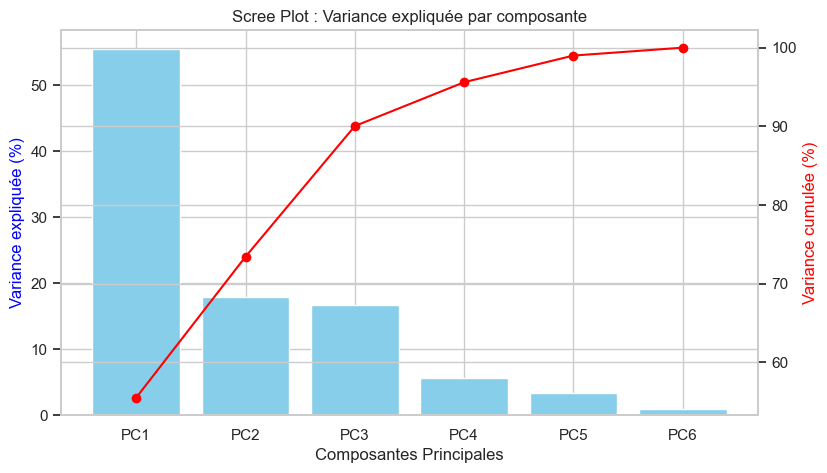

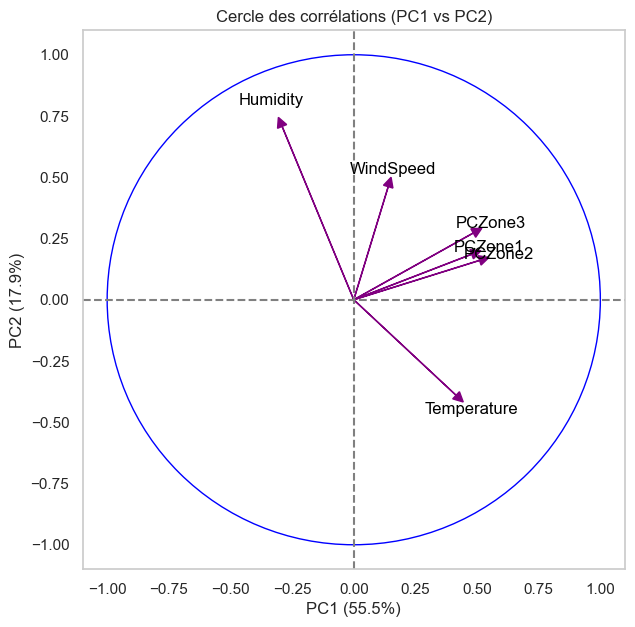

In [15]:
# --- 2. ANALYSE EN COMPOSANTES PRINCIPALES (ACP) ---

# Sélection des variables requises pour l'ACP
features = ['Temperature', 'Humidity', 'WindSpeed', 'PCZone1', 'PCZone2', 'PCZone3']
X = df[features]

# [Graded Question 1] Calcul des variances
print("--- Variances des variables ---")
display(X.var().round(3))

# [Graded Question 2] Calcul de la matrice de corrélation
print("\n--- Matrice de corrélation ---")
display(X.corr().round(3))

# Standardisation obligatoire (Centrage et réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Application de l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# [Graded Question 3] Vecteurs de chargement (Loadings)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(6)], index=features)
print("\n--- Vecteurs de chargement (Loadings) ---")
display(loadings.round(3))

# [Graded Question 4] Pourcentage de variance expliquée (PVE)
pve = pca.explained_variance_ratio_
pve_cumule = np.cumsum(pve)

print("\n--- Pourcentage de Variance Expliquée (PVE) ---")
for i in range(6):
    print(f"PC{i+1} : PVE = {pve[i]*100:.2f}% | PVE Cumulé = {pve_cumule[i]*100:.2f}%")

# Graphique du PVE (Scree plot / Éboulis des valeurs propres)
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar([f'PC{i+1}' for i in range(6)], pve*100, color='skyblue', label='Variance individuelle')
ax1.set_ylabel('Variance expliquée (%)', color='blue')
ax1.set_xlabel('Composantes Principales')

ax2 = ax1.twinx()
ax2.plot([f'PC{i+1}' for i in range(6)], pve_cumule*100, color='red', marker='o', label='Variance cumulée')
ax2.set_ylabel('Variance cumulée (%)', color='red')
plt.title("Scree Plot : Variance expliquée par composante")
plt.show()

# [Graded Question 5] Plot du cercle des corrélations
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

cercle = plt.Circle((0,0), 1, color='blue', fill=False)
ax.add_artist(cercle)

for i, feature in enumerate(features):
    x_val = loadings.iloc[i, 0] # PC1
    y_val = loadings.iloc[i, 1] # PC2
    ax.arrow(0, 0, x_val, y_val, head_width=0.04, head_length=0.04, color='purple')
    ax.text(x_val * 1.15, y_val * 1.15, feature, color='black', ha='center', va='center')

plt.title("Cercle des corrélations (PC1 vs PC2)")
plt.xlabel(f"PC1 ({pve[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pve[1]*100:.1f}%)")
plt.grid()
plt.show()

--- 2.4.1 Simple Linear Regression ---
Corrélations avec la cible PCZone1 :


Temperature    0.456
Humidity      -0.267
WindSpeed      0.055
PCZone2        0.923
PCZone3        0.759
dtype: float64


La variable la plus corrélée avec PCZone1 est : PCZone2


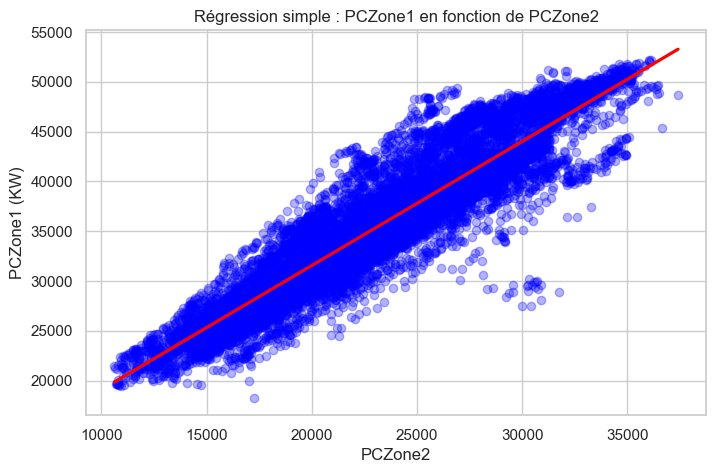


--- Résumé du modèle linéaire simple ---
                            OLS Regression Results                            
Dep. Variable:                PCZone1   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                 7.656e+04
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:38:29   Log-Likelihood:            -1.2355e+05
No. Observations:               13248   AIC:                         2.471e+05
Df Residuals:                   13246   BIC:                         2.471e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

In [18]:
# --- 3. RÉGRESSION LINÉAIRE ---
target = 'PCZone1'
predictors = ['Temperature', 'Humidity', 'WindSpeed', 'PCZone2', 'PCZone3']

# --- 2.4.1 Régression Linéaire Simple ---
print("--- 2.4.1 Simple Linear Regression ---")

# Calcul des corrélations avec la cible
correlations = df[predictors].corrwith(df[target])
print("Corrélations avec la cible PCZone1 :")
display(correlations.round(3))

# Identification du prédicteur le plus corrélé
most_correlated_var = correlations.abs().idxmax()
print(f"\nLa variable la plus corrélée avec PCZone1 est : {most_correlated_var}")

# Graphique de la cible VS le meilleur prédicteur
plt.figure(figsize=(8, 5))
sns.regplot(x=most_correlated_var, y=target, data=df, 
            scatter_kws={'alpha': 0.3, 'color': 'blue'}, line_kws={'color': 'red'})
plt.title(f"Régression simple : {target} en fonction de {most_correlated_var}")
plt.xlabel(f"{most_correlated_var}")
plt.ylabel(f"{target} (KW)")
plt.show()

# Ajustement du modèle de régression linéaire simple
X_simple = sm.add_constant(df[most_correlated_var]) # Ajout de la constante beta_0
model_simple = sm.OLS(df[target], X_simple).fit()

# Affichage du rapport d'analyse complet
print("\n--- Résumé du modèle linéaire simple ---")
print(model_simple.summary())


# --- 2.4.2 Sélection de variables pour la Régression Multiple ---
print("\n--- 2.4.2 Feature Selection (Best Subset Selection) ---")

best_adj_r2 = -1
best_features = None
best_model = None

# Parcours de toutes les tailles de sous-ensembles possibles (de 1 à 5)
for k in range(1, len(predictors) + 1):
    for combo in itertools.combinations(predictors, k):
        # Configuration de la matrice de design avec constante
        X_subset = sm.add_constant(df[list(combo)])
        model = sm.OLS(df[target], X_subset).fit()
        
        # Sélection basée sur le R² ajusté maximum
        if model.rsquared_adj > best_adj_r2:
            best_adj_r2 = model.rsquared_adj
            best_features = combo
            best_model = model

print(f"Nombre de variables conservées : {len(best_features)}")
print(f"Variables sélectionnées : {best_features}")
print(f"Meilleur R² ajusté obtenu : {best_adj_r2:.3f}")

# Affichage du rapport d'analyse du meilleur modèle multiple
print("\n--- Résumé du meilleur modèle multiple ---")
print(best_model.summary())


# --- Prédiction finale ---
print("\n--- Prédiction de la consommation ---")

# Données d'entrée fournies pour la prédiction
input_values = {
    'const': 1.0,
    'Temperature': 26.0,
    'Humidity': 65.0,
    'WindSpeed': 4.2,
    'PCZone2': 18840.0,
    'PCZone3': 25700.0
}

# Extraction automatique des variables requises par le modèle sélectionné
prediction_data = {feat: input_values[feat] for feat in ['const'] + list(best_features)}
prediction_df = prediction_df[list(best_model.model.exog_names)]

# Calcul de la prédiction
prediction_result = best_model.predict(prediction_df)[0]
print(f"Consommation prédite pour PCZone1 : {prediction_result:.3f} KW")